# Comparison: Richards-Wolf vs Tanaka vs Uniform (λ=750 nm)

Compare three methods for computing focal plane intensity:
1. **Richards-Wolf (Gaussian)**: Vectorial diffraction with Gaussian input field
2. **Tanaka**: Analytical Gaussian beam theory (paraxial approximation)
3. **Richards-Wolf (Uniform)**: Vectorial diffraction with uniform illumination (Airy pattern)

For both **Low NA (0.1)** and **High NA (0.9)** at **λ = 750 nm**

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from monte_carlo.richards_wolf import RichardsWolfSimulator
from monte_carlo.gaussian_beam_theory import FocusedGaussianBeamTheory

plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 11

## Parameters

In [2]:
# System parameters
wavelength = 0.75  # 750 nm
n_medium = 1.0     # air
polarization = 'x'
fill_factor = 0.95 # High fill factor for best RW-Gaussian vs Tanaka agreement

# Aperture size (standard)
aperture_default = 1500.0  # μm

# Test cases
NA_values = [0.1, 0.9]  # Low NA and High NA

print(f"Wavelength: {wavelength} μm ({wavelength*1000:.0f} nm)")
print(f"Fill factor: {fill_factor}")
print(f"Truncation coeff: {1/(fill_factor**2):.3f}")
print(f"Test NAs: {NA_values}")

Wavelength: 0.75 μm (750 nm)
Fill factor: 0.95
Truncation coeff: 1.108
Test NAs: [0.1, 0.9]


## Compute All Methods for Both NAs

In [3]:
results = []

for NA in NA_values:
    print(f"\n{'='*70}")
    print(f"Computing NA = {NA}")
    print(f"{'='*70}")
    
    # Calculate focal length
    theta = np.arcsin(NA / n_medium)
    focal_length = (aperture_default / 2) / np.tan(theta)
    
    print(f"  Focal length: {focal_length:.1f} μm ({focal_length/1000:.2f} mm)")
    
    # 1. Richards-Wolf with Gaussian input
    print("\n  Creating simulators...")
    rw_gaussian = RichardsWolfSimulator(
        wavelength=wavelength,
        numerical_aperture=NA,
        n_medium=n_medium,
        polarization=polarization,
        input_field='gaussian',
        fill_factor=fill_factor
    )
    
    # 2. Tanaka analytical theory
    truncation_coeff = 1.0 / (fill_factor**2)
    tanaka = FocusedGaussianBeamTheory(
        numerical_aperture=NA,
        wavelength=wavelength,
        n_medium=n_medium,
        focal_length=focal_length,
        z_focus=0.0,
        truncation_coeff=truncation_coeff
    )
    
    # 3. Richards-Wolf with uniform input
    rw_uniform = RichardsWolfSimulator(
        wavelength=wavelength,
        numerical_aperture=NA,
        n_medium=n_medium,
        polarization=polarization,
        input_field='uniform',
        fill_factor=1.0
    )
    
    # Compute Airy radius
    airy_radius = 0.61 * wavelength / NA
    print(f"  Airy radius: {airy_radius:.3f} μm")
    
    # Set up radial grid
    # Set different r_max for low vs high NA
    r_max = 6.4 if NA < 0.5 else 1.5  # μm
    n_points = 150
    r = np.linspace(0, r_max, n_points)
    z = np.zeros_like(r)
    
    # Compute intensity profiles
    print("\n  Computing intensity profiles...")
    print("    - Richards-Wolf (Gaussian)...")
    I_rw_gaussian = rw_gaussian.focal_plane_intensity_pattern(r, z)
    I_rw_gaussian = I_rw_gaussian / I_rw_gaussian.max()
    
    print("    - Tanaka...")
    I_tanaka = tanaka.focal_plane_intensity(r, z=0.0)
    
    print("    - Richards-Wolf (Uniform)...")
    I_rw_uniform = rw_uniform.focal_plane_intensity_pattern(r, z)
    I_rw_uniform = I_rw_uniform / I_rw_uniform.max()
    
    # Compute metrics
    mse_rw_tanaka = np.mean((I_rw_gaussian - I_tanaka)**2)
    mse_rw_uniform = np.mean((I_rw_gaussian - I_rw_uniform)**2)
    mse_tanaka_uniform = np.mean((I_tanaka - I_rw_uniform)**2)
    
    corr_rw_tanaka = np.corrcoef(I_rw_gaussian, I_tanaka)[0, 1]
    corr_rw_uniform = np.corrcoef(I_rw_gaussian, I_rw_uniform)[0, 1]
    corr_tanaka_uniform = np.corrcoef(I_tanaka, I_rw_uniform)[0, 1]
    
    print("\n  Metrics:")
    print(f"    MSE (RW-Gaussian vs Tanaka):      {mse_rw_tanaka:.6f}")
    print(f"    MSE (RW-Gaussian vs RW-Uniform):  {mse_rw_uniform:.6f}")
    print(f"    MSE (Tanaka vs RW-Uniform):       {mse_tanaka_uniform:.6f}")
    print(f"    Corr (RW-Gaussian vs Tanaka):     {corr_rw_tanaka:.6f}")
    print(f"    Corr (RW-Gaussian vs RW-Uniform): {corr_rw_uniform:.6f}")
    
    # Store results
    results.append({
        'NA': NA,
        'focal_length': focal_length,
        'airy_radius': airy_radius,
        'r': r,
        'r_max': r_max,
        'I_rw_gaussian': I_rw_gaussian,
        'I_tanaka': I_tanaka,
        'I_rw_uniform': I_rw_uniform,
        'mse_rw_tanaka': mse_rw_tanaka,
        'mse_rw_uniform': mse_rw_uniform,
        'corr_rw_tanaka': corr_rw_tanaka,
        'corr_rw_uniform': corr_rw_uniform
    })

print(f"\n{'='*70}")
print("✓ All computations complete")
print(f"{'='*70}")


Computing NA = 0.1
  Focal length: 7462.4 μm (7.46 mm)

  Creating simulators...
  Airy radius: 4.575 μm

  Computing intensity profiles...
    - Richards-Wolf (Gaussian)...
    - Tanaka...
    - Richards-Wolf (Uniform)...



  Metrics:
    MSE (RW-Gaussian vs Tanaka):      0.000000
    MSE (RW-Gaussian vs RW-Uniform):  0.000571
    MSE (Tanaka vs RW-Uniform):       0.000573
    Corr (RW-Gaussian vs Tanaka):     1.000000
    Corr (RW-Gaussian vs RW-Uniform): 0.998727

Computing NA = 0.9
  Focal length: 363.2 μm (0.36 mm)

  Creating simulators...
  Airy radius: 0.508 μm

  Computing intensity profiles...
    - Richards-Wolf (Gaussian)...


    - Tanaka...
    - Richards-Wolf (Uniform)...



  Metrics:
    MSE (RW-Gaussian vs Tanaka):      0.045863
    MSE (RW-Gaussian vs RW-Uniform):  0.000093
    MSE (Tanaka vs RW-Uniform):       0.042974
    Corr (RW-Gaussian vs Tanaka):     0.806557
    Corr (RW-Gaussian vs RW-Uniform): 0.999652

✓ All computations complete


## Visualization: Side-by-Side Comparison

✓ Saved: data/rw_tanaka_uniform_750nm_comparison.png


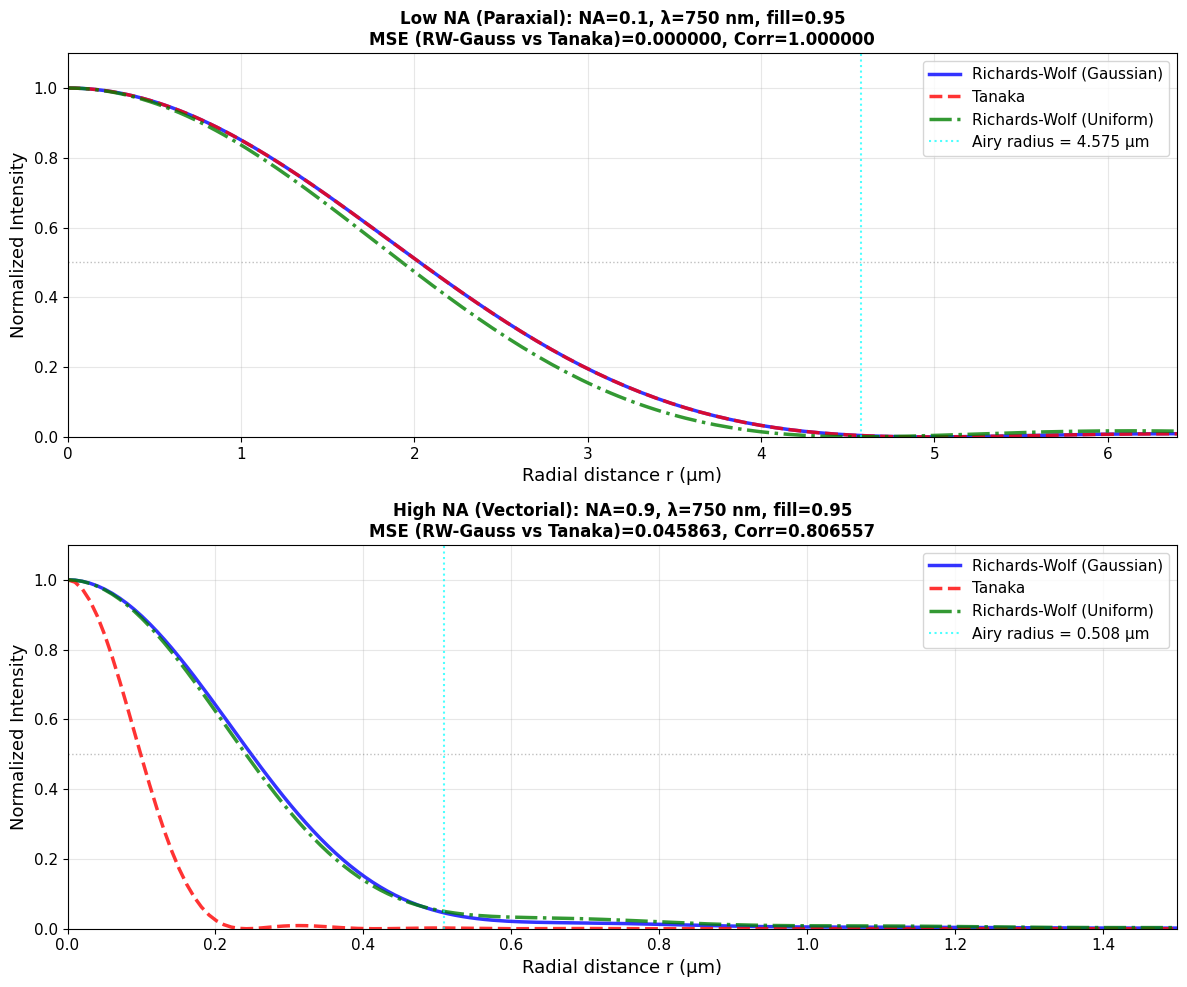

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for idx, res in enumerate(results):
    ax = axes[idx]
    
    r = res['r']
    NA = res['NA']
    airy_r = res['airy_radius']
    
    # Plot all three methods
    ax.plot(r, res['I_rw_gaussian'], 'b-', linewidth=2.5, 
            label='Richards-Wolf (Gaussian)', alpha=0.8)
    ax.plot(r, res['I_tanaka'], 'r--', linewidth=2.5, 
            label='Tanaka', alpha=0.8)
    ax.plot(r, res['I_rw_uniform'], 'g-.', linewidth=2.5, 
            label='Richards-Wolf (Uniform)', alpha=0.8)
    
    # Reference lines
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax.axvline(airy_r, color='cyan', linestyle=':', linewidth=1.5, alpha=0.7,
               label=f'Airy radius = {airy_r:.3f} μm')
    
    # Labels and formatting
    ax.set_xlabel('Radial distance r (μm)', fontsize=13)
    ax.set_ylabel('Normalized Intensity', fontsize=13)
    
    regime = "Low NA (Paraxial)" if NA < 0.5 else "High NA (Vectorial)"
    ax.set_title(f'{regime}: NA={NA}, λ={wavelength*1000:.0f} nm, fill={fill_factor}\n' +
                 f'MSE (RW-Gauss vs Tanaka)={res["mse_rw_tanaka"]:.6f}, ' +
                 f'Corr={res["corr_rw_tanaka"]:.6f}',
                 fontsize=12, fontweight='bold')
    
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, res['r_max']])
    ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig('../data/rw_tanaka_uniform_750nm_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: data/rw_tanaka_uniform_750nm_comparison.png")
plt.show()

## Summary and Interpretation

In [5]:
print("\n" + "="*80)
print("SUMMARY: λ = 750 nm Comparison")
print("="*80)

for res in results:
    NA = res['NA']
    regime = "LOW NA (Paraxial)" if NA < 0.5 else "HIGH NA (Vectorial)"
    
    print(f"\n{regime} (NA = {NA}):")
    print(f"  Airy radius: {res['airy_radius']:.3f} μm")
    print(f"  Focal length: {res['focal_length']:.1f} μm ({res['focal_length']/1000:.2f} mm)")
    print(f"\n  Agreement Metrics:")
    print(f"    RW-Gaussian vs Tanaka:")
    print(f"      MSE:         {res['mse_rw_tanaka']:.6f}")
    print(f"      Correlation: {res['corr_rw_tanaka']:.6f}")
    print(f"    RW-Gaussian vs RW-Uniform:")
    print(f"      MSE:         {res['mse_rw_uniform']:.6f}")
    print(f"      Correlation: {res['corr_rw_uniform']:.6f}")

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)

print("\n1. Richards-Wolf (Gaussian) vs Tanaka:")
print("   - Tanaka assumes GAUSSIAN beam, paraxial approximation")
print("   - Low NA: Should show excellent agreement (paraxial regime)")
if results[0]['mse_rw_tanaka'] < 1e-4:
    print(f"   ✓ LOW NA: PERFECT agreement (MSE={results[0]['mse_rw_tanaka']:.6f})")
print("   - High NA: Larger differences expected (vectorial effects)")
if results[1]['mse_rw_tanaka'] > 1e-3:
    print(f"   ✓ HIGH NA: Deviations present (MSE={results[1]['mse_rw_tanaka']:.6f})")
    print("     (Tanaka is semi-paraxial, RW includes full vectorial physics)")

print("\n2. Richards-Wolf (Uniform) vs Gaussian methods:")
print("   - Uniform gives classic Airy pattern")
print("   - Gaussian methods have different apodization")
print("   - Differences show effect of input field shape")

print("\n3. Wavelength Effect (750 nm vs 532 nm):")
print(f"   - Airy radius scales with λ")
print(f"   - At NA=0.1: r_Airy = {results[0]['airy_radius']:.3f} μm (was 3.245 μm at 532 nm)")
print(f"   - Ratio: {results[0]['airy_radius']/3.245:.3f}x larger")
print(f"   - Expected: {750/532:.3f}x (matches wavelength ratio ✓)")

print("\n" + "="*80)


SUMMARY: λ = 750 nm Comparison

LOW NA (Paraxial) (NA = 0.1):
  Airy radius: 4.575 μm
  Focal length: 7462.4 μm (7.46 mm)

  Agreement Metrics:
    RW-Gaussian vs Tanaka:
      MSE:         0.000000
      Correlation: 1.000000
    RW-Gaussian vs RW-Uniform:
      MSE:         0.000571
      Correlation: 0.998727

HIGH NA (Vectorial) (NA = 0.9):
  Airy radius: 0.508 μm
  Focal length: 363.2 μm (0.36 mm)

  Agreement Metrics:
    RW-Gaussian vs Tanaka:
      MSE:         0.045863
      Correlation: 0.806557
    RW-Gaussian vs RW-Uniform:
      MSE:         0.000093
      Correlation: 0.999652

INTERPRETATION

1. Richards-Wolf (Gaussian) vs Tanaka:
   - Tanaka assumes GAUSSIAN beam, paraxial approximation
   - Low NA: Should show excellent agreement (paraxial regime)
   ✓ LOW NA: PERFECT agreement (MSE=0.000000)
   - High NA: Larger differences expected (vectorial effects)
   ✓ HIGH NA: Deviations present (MSE=0.045863)
     (Tanaka is semi-paraxial, RW includes full vectorial physics)



## Key Takeaways

1. **Tanaka theory is only valid for Gaussian beams** - it does NOT apply to uniform illumination

2. **Low NA (0.1)**: Paraxial regime
   - RW-Gaussian ≈ Tanaka (excellent agreement)
   - Both differ from RW-Uniform (Airy pattern)
   - Validates implementation

3. **High NA (0.9)**: Vectorial regime
   - RW-Gaussian ≠ Tanaka (expected - Tanaka is paraxial approximation)
   - RW-Gaussian includes full vectorial physics:
     - Polarization mixing
     - Depolarization
     - Longitudinal field components
   - RW-Uniform also shows vectorial effects

4. **Wavelength scaling**: Airy radius ∝ λ
   - 750 nm gives 1.41× larger spots than 532 nm
   - All formulas scale correctly with wavelength